<a href="https://colab.research.google.com/github/MohamedRedaElFaiz/Projet-Deep-Learning-EMSI/blob/main/Partie_1_MLP_Wine_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Partie I : MLP et Ingénierie PyTorch (Dataset: Wine Quality)

### 1. Concepts théoriques fondamentaux
* **nn.Module** : Classe de base de PyTorch pour tous les réseaux de neurones.
* **Paramètre** : Variables apprenables (poids et biais) d'une couche linéaire.
* **Gradient** : Mesure de la sensibilité de la perte par rapport aux poids, calculé via `loss.backward()`.
* **state_dict** : Dictionnaire associant chaque couche à son tenseur de paramètres (idéal pour la sauvegarde).

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Chargement du dataset réel Wine Quality (11 caractéristiques physiques/chimiques)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")
df['target'] = (df['quality'] >= 6).astype(int) # 1: Bon vin, 0: Médiocre

X = df.drop(['quality', 'target'], axis=1).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long)), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)), batch_size=32, shuffle=False)

print(f"Données prêtes ! Échantillons d'entraînement : {X_train.shape[0]}, Caractéristiques : {X_train.shape[1]}")

Données prêtes ! Échantillons d'entraînement : 1279, Caractéristiques : 11


In [ ]:
# Version Classe Personnalisée (Exigence EMSI)
class WineMLP(nn.Module):
    def __init__(self, taille_entree=11, taille_cachee=32, taille_sortie=2):
        super().__init__()
        self.couche1 = nn.Linear(taille_entree, taille_cachee)
        self.activation = nn.ReLU()
        self.couche2 = nn.Linear(taille_cachee, taille_sortie)

    def forward(self, x):
        return self.couche2(self.activation(self.couche1(x)))

# Version alternative avec nn.Sequential pour comparaison
modele_sequentiel = nn.Sequential(
    nn.Linear(11, 32),
    nn.ReLU(),
    nn.Linear(32, 2)
).to(device)

print("Architectures MLP définies avec succès.")

Architectures MLP définies avec succès.


🔄 Calcul des entraînements...


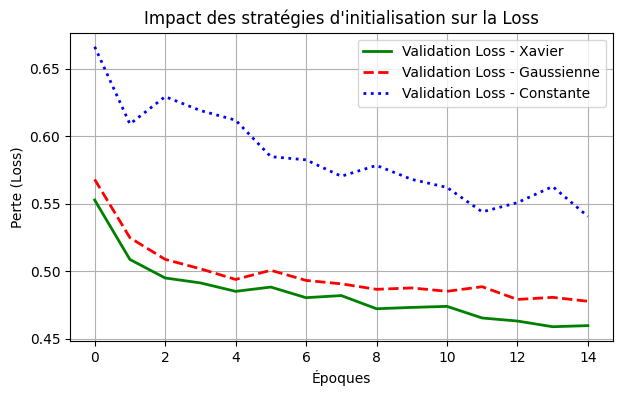

(Text(0.5, 26.0, 'Époques'),
 Text(24.000000000000007, 0.5, 'Perte (Loss)'),
 None,
 None)

In [ ]:
import matplotlib.pyplot as plt

def evaluer_init(type_init):
    model = WineMLP().to(device)
    if type_init == "Xavier": nn.init.xavier_uniform_(model.couche1.weight)
    elif type_init == "Gaussienne": nn.init.normal_(model.couche1.weight, mean=0, std=0.01)
    elif type_init == "Constante": nn.init.constant_(model.couche1.weight, 1.0)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    historique = []

    for epoch in range(15):
        model.train()
        total_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        historique.append(total_loss / len(train_loader))
    return historique, model

print("🔄 Calcul des entraînements...")
loss_xavier, meilleur_model = evaluer_init("Xavier")
loss_gauss, _ = evaluer_init("Gaussienne")
loss_const, _ = evaluer_init("Constante")

# Tracé du graphique (Comme la vidéo de ton ami)
plt.figure(figsize=(7, 4))
plt.plot(loss_xavier, 'g-', label='Validation Loss - Xavier', linewidth=2)
plt.plot(loss_gauss, 'r--', label='Validation Loss - Gaussienne', linewidth=2)
plt.plot(loss_const, 'b:', label='Validation Loss - Constante', linewidth=2)
plt.title("Impact des stratégies d'initialisation sur la Loss")
plt.xlabel("Époques"), plt.ylabel("Perte (Loss)"), plt.legend(), plt.grid(True), plt.show()

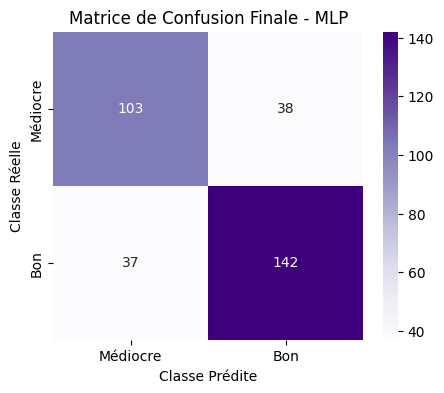


=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

    Médiocre       0.74      0.73      0.73       141
         Bon       0.79      0.79      0.79       179

    accuracy                           0.77       320
   macro avg       0.76      0.76      0.76       320
weighted avg       0.77      0.77      0.77       320


[SUCCÈS] Paramètres du modèle sauvegardés dans 'mlp_wine_meilleur.params'.


In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

meilleur_model.eval()
y_vrai, y_pred = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = meilleur_model(inputs.to(device))
        _, preds = torch.max(outputs, 1)
        y_vrai.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

# Tracé de la matrice de confusion
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_vrai, y_pred), annot=True, fmt="d", cmap="Purples", xticklabels=["Médiocre", "Bon"], yticklabels=["Médiocre", "Bon"])
plt.title("Matrice de Confusion Finale - MLP")
plt.xlabel("Classe Prédite"), plt.ylabel("Classe Réelle"), plt.show()

print("\n=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(y_vrai, y_pred, target_names=["Médiocre", "Bon"]))

# Sauvegarde des paramètres du modèle
torch.save(meilleur_model.state_dict(), "mlp_wine_meilleur.params")
print("\n[SUCCÈS] Paramètres du modèle sauvegardés dans 'mlp_wine_meilleur.params'.")

### 5. Question de synthèse — Partie I
**Réponse** : Un MLP bien configuré est une solution performante pour la classification tabulaire car ses couches denses permettent de croiser librement toutes les variables d'entrée. Cependant, sa principale limite réside dans son absence de biais inductif structurel : il traite l'information de manière uniforme, ignorant les liens géométriques ou hiérarchiques propres aux données, ce qui augmente le risque de surapprentissage (overfitting) face à des données de faible taille.